In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

In [8]:
# Parameters for both functions
T0 = 373.15       # K
h = 10            # W/m^2·K
Ta = 273.15 + 10  # K
k = [382, 204, 62.3, 14.9]  # [0=copper, 1=aluminum, 2=iron, 3=steel] W/m·K

In [9]:
# Fin model with change of variables
def model(r, z, k):
    B = 0.001  # m
    dz1 = z[1]
    dz2 = -1/r * z[1] + 2 * h / (B * k) * (z[0] - Ta)
    dz3 = 4 * np.pi * r * h * (z[0] - Ta)
    return [dz1, dz2, dz3]

In [10]:
# Model that integrates the fin equation and returns fcosto, which represents
# the boundary condition at r = R1 for the four materials: conduction equals convection
def fin(param, k):
    r = (0.01, 0.1)
    rvalues = np.linspace(0.01, 0.1, 100)
    T1 = solve_ivp(model, r, [T0, param[0], 0], args=(k[0],), t_eval=rvalues).y
    T2 = solve_ivp(model, r, [T0, param[1], 0], args=(k[1],), t_eval=rvalues).y
    T3 = solve_ivp(model, r, [T0, param[2], 0], args=(k[2],), t_eval=rvalues).y
    T4 = solve_ivp(model, r, [T0, param[3], 0], args=(k[3],), t_eval=rvalues).y

    fcosto = 1000 * (
        (k[0] * T1[1, -1] + h * (T1[0, -1] - Ta))**2 +
        (k[1] * T2[1, -1] + h * (T2[0, -1] - Ta))**2 +
        (k[2] * T3[1, -1] + h * (T3[0, -1] - Ta))**2 +
        (k[3] * T4[1, -1] + h * (T4[0, -1] - Ta))**2
    )
    return fcosto

In [11]:
# Optimization routine
# To satisfy the condition conduction = convection at the fin tip, we seek the optimal vector "param"
initial_guess = [-1000] * 4
result = minimize(fin, initial_guess, args=(k,), method='Powell', tol=1e-9)

print(result)
params_opt = result.x

print(f'\nOptimized initial conditions: {np.round(params_opt, 2)}')
print(f'Cost function evaluated at the optimum: {np.round(result.fun, 8)}')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 7.42141000170411e-17
       x: [-1.669e+03 -2.507e+03 -4.325e+03 -6.694e+03]
     nit: 3
   direc: [[ 1.000e+00  0.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]
    nfev: 118

Optimized initial conditions: [-1669.   -2506.51 -4325.4  -6694.1 ]
Cost function evaluated at the optimum: 0.0


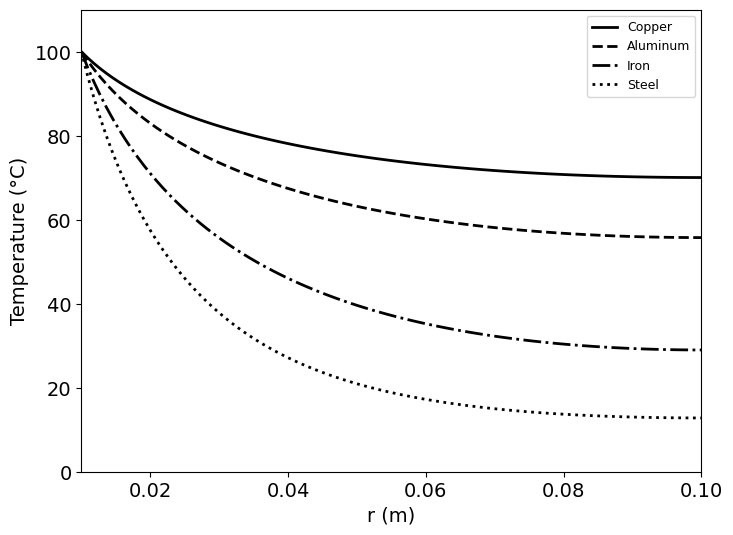

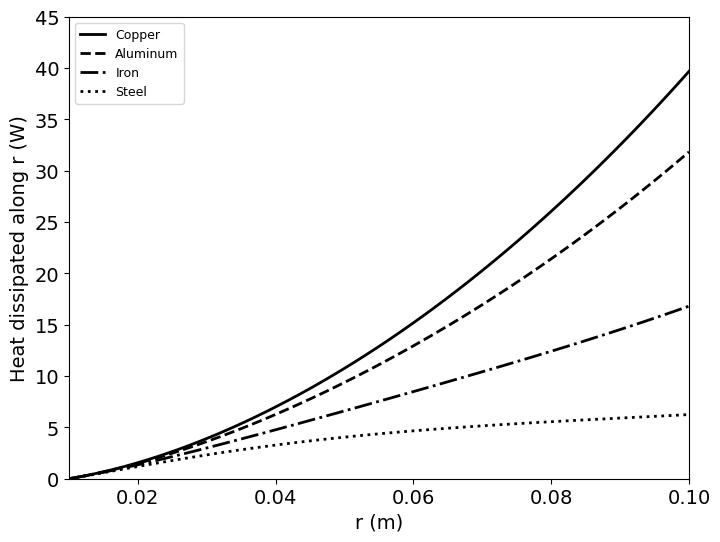

In [12]:
# Plotting the temperature and total heat loss for the four cases
# Line style configuration
line_styles = ['-', '--', '-.', ':']

# Integration range
r = (0.01, 0.1)
rvalues = np.linspace(0.01, 0.1, 100)

materials = ['Copper', 'Aluminum', 'Iron', 'Steel']
for i in range(4):
    T = solve_ivp(model, r, [T0, params_opt[i], 0], args=(k[i],), t_eval=rvalues).y
    
    # Temperature
    plt.figure(1, figsize=(8, 6))
    plt.plot(rvalues, T[0] - 273.15, color='k',
             label=materials[i], linestyle=line_styles[i], lw=2)
    plt.xlabel('r (m)', fontsize=14)
    plt.xlim(0.01, 0.1)
    plt.ylabel('Temperature (°C)', fontsize=14)
    plt.ylim(0, 110)
    plt.legend(loc='best', fontsize=9)
    plt.tick_params(axis='both', labelsize=14)

    # Heat dissipated
    plt.figure(2, figsize=(8, 6))
    plt.plot(rvalues, T[2], color='k',
             label=materials[i], linestyle=line_styles[i], lw=2)
    plt.xlabel('r (m)', fontsize=14)
    plt.xlim(0.01, 0.1)
    plt.ylabel('Heat dissipated along r (W)', fontsize=14)
    plt.ylim(0, 45)
    plt.legend(loc='best', fontsize=9)
    plt.tick_params(axis='both', labelsize=14)

plt.show()